### DAY 3

#### Oil & Gas Data Research, Web Scraping and Analysis

### Business Problem
Which countries have the fastest growth in oil consumption (2015–2023)
We want to see:
- Which countries are using more oil over time
- Who is growing fastest
- Who increased the most

### Datasets I need
- Countries
- Year
- Oil consumption

In [5]:
import pandas as pd
import numpy as np

In [21]:
# 1) Load dataset

df = pd.read_csv("oil-consumption-by-country (1).csv")

In [23]:
df.head()

,Entity,Code,Year,Oil consumption - TWh
0,Africa,NaN,1965,341.07257
1,Africa,NaN,1966,369.46457
2,Africa,NaN,1967,368.28156
3,Africa,NaN,1968,389.57162
4,Africa,NaN,1969,397.37260


The Data is a long table (one row per country per year)

#### Data Cleaning

✔ Rename columns

✔ Keep only years 2015 to 2023

✔ Remove non-country aggregates manually because the dataset from OWID contains not only real countries, but also: World, Africa, Europe, Asia, European Union, North America and South America. These are regions, not countries. And the business problem is: **Which COUNTRIES have the fastest growth in oil consumption?** So we must remove regions.

In [27]:
# 2) Tidy columns 
value_col = [c for c in df.columns if c not in ["Entity", "Code", "Year"]][0]
df = df.rename(columns={"Entity": "country", "Year": "year", value_col: "oil_consumption_twh"})

# 3) Filter years
df = df[(df["year"] >= 2015) & (df["year"] <= 2023)].copy()


In [29]:
# Remove non-country aggregates manually
exclude = ["World", "Asia", "Europe", "Africa", "European Union", "North America", "South America"]
df = df[~df["country"].isin(exclude)]

In [31]:
# remove aggregates (World, regions) by keeping rows with a 3-letter country code
# (OWID country codes are usually 3 letters; regions often have blank codes or OWID_ codes)
df = df[df["Code"].notna() & (df["Code"].str.len() == 3)].copy()

# Save cleaned time series
df.to_csv("oil_consumption_country_year_2015_2023.csv", index=False)

In [33]:
df

,country,Code,year,oil_consumption_twh
170,Algeria,DZA,2015,236.14848
171,Algeria,DZA,2016,229.56384
172,Algeria,DZA,2017,225.51212
173,Algeria,DZA,2018,227.78590
174,Algeria,DZA,2019,236.95130
...,...,...,...,...
6279,Vietnam,VNM,2019,339.07135
6280,Vietnam,VNM,2020,307.29740
6281,Vietnam,VNM,2021,288.10876
6282,Vietnam,VNM,2022,337.13995


### DAY 4

### To Answer Business Question
First:

✔ Convert the data from Long to wide form because to calculate growth, We need: starting year (2015) and ending year (2023)

✔ Create new columns:
- oil_2015 (Just a copy of 2015 column.)
- oil_2023 (Just a copy of 2023 column.)
- Absolute change (How much more oil does the country use now compared to 2015?)
- Percent change (By what % did oil use grow?)
- CAGR (Compound Annual Growth Rate) (most important) (If oil use grew smoothly every year, what would the yearly growth rate be?)

✔ Rank by countries

In [37]:
# Build growth table
wide = df.pivot_table(index=["country", "Code"], columns="year", values="oil_consumption_twh", aggfunc="sum")

In [39]:
# Keep only countries with both endpoints
wide = wide.dropna(subset=[2015, 2023])

wide["oil_2015"] = wide[2015]
wide["oil_2023"] = wide[2023]
wide["abs_change_twh"] = wide["oil_2023"] - wide["oil_2015"]
wide["pct_change_%"] = (wide["oil_2023"] / wide["oil_2015"] - 1) * 100
wide["cagr_%"] = ((wide["oil_2023"] / wide["oil_2015"]) ** (1/8) - 1) * 100

rank = wide.reset_index().sort_values("cagr_%", ascending=False)

rank.to_csv("oil_consumption_growth_rankings_2015_2023.csv", index=False)

rank.head(10)

year,country,Code,2015,2016,2017,2018,2019,2020,2021,2022,2023,oil_2015,oil_2023,abs_change_twh,pct_change_%,cagr_%
5,Bangladesh,BGD,92.684460,96.11049,108.253540,124.193970,121.872680,102.776375,140.567490,166.14375,139.369220,92.684460,139.369220,46.684760,50.369566,5.231314
76,Uzbekistan,UZB,45.713093,51.62207,52.311237,55.786903,59.383640,61.754055,62.585205,65.60801,66.172714,45.713093,66.172714,20.459621,44.756589,4.732095
78,Vietnam,VNM,250.782550,271.99347,294.575530,320.087340,339.071350,307.297400,288.108760,337.13995,362.139620,250.782550,362.139620,111.357070,44.403835,4.700159
12,China,CHN,6609.895500,6823.57860,7183.172000,7528.741000,7891.510300,7959.667000,8174.094700,8198.39300,9091.228000,6609.895500,9091.228000,2481.332500,37.539663,4.064714
31,Iraq,IRQ,391.297500,396.54950,478.249100,470.879670,458.795350,397.995880,444.499660,488.49573,520.973630,391.297500,520.973630,129.676130,33.140035,3.642668
52,Poland,POL,292.993200,321.58720,362.947100,372.288700,379.484530,359.474640,375.108250,389.42603,388.326600,292.993200,388.326600,95.333400,32.537752,3.583946
4,Azerbaijan,AZE,55.601353,55.19285,55.699093,62.740920,63.158752,57.751200,65.339250,69.25950,72.102280,55.601353,72.102280,16.500927,29.677204,3.301816
70,Turkey,TUR,498.664100,533.83057,578.778440,579.382140,576.530800,547.577400,581.604550,606.45300,645.444950,498.664100,645.444950,146.780850,29.434814,3.277660
28,India,IND,2296.038600,2514.26170,2588.196000,2704.512200,2791.946300,2537.852500,2588.831300,2804.53030,2939.235000,2296.038600,2939.235000,643.196400,28.013310,3.135194
13,Colombia,COL,200.190460,224.96028,221.976970,232.515730,231.360170,192.891860,227.327880,266.85062,254.751970,200.190460,254.751970,54.561510,27.254800,3.058608


Between **2015 and 2023, Bangladesh, Uzbekistan, and Vietnam** recorded the fastest growth in oil consumption, driven likely by industrialization and transport demand.

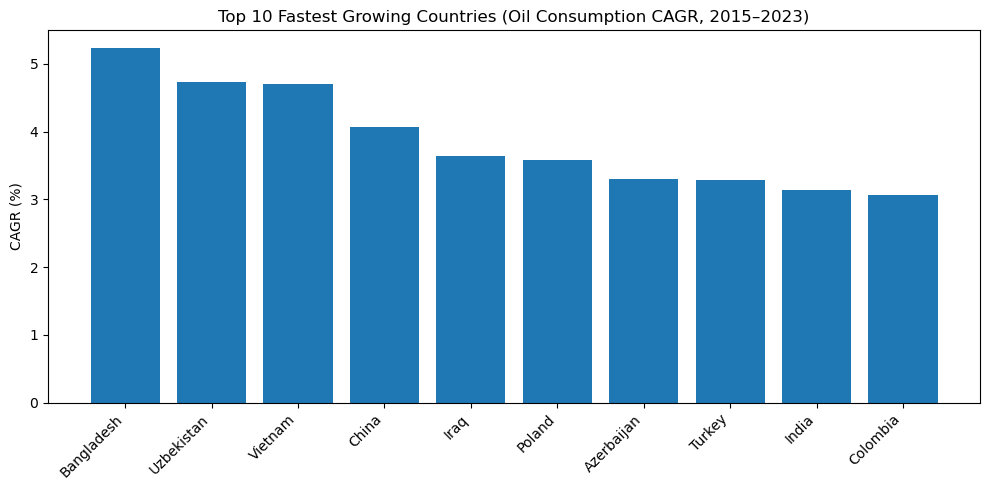

In [42]:
import matplotlib.pyplot as plt

top10_cagr = rank.sort_values("cagr_%", ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top10_cagr["country"], top10_cagr["cagr_%"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("CAGR (%)")
plt.title("Top 10 Fastest Growing Countries (Oil Consumption CAGR, 2015–2023)")
plt.tight_layout()
plt.show()


**Key insights:**

- **Bangladesh, Uzbekistan, and Vietnam** show the highest growth rates, pointing to rapid increases in transport fuel use and industrial activity.

- **China appears in the top 10** despite already being a large consumer, indicating that it is growing both in size and speed.

- Several countries in the list are emerging or middle-income economies, suggesting that future oil demand growth is shifting toward developing markets.

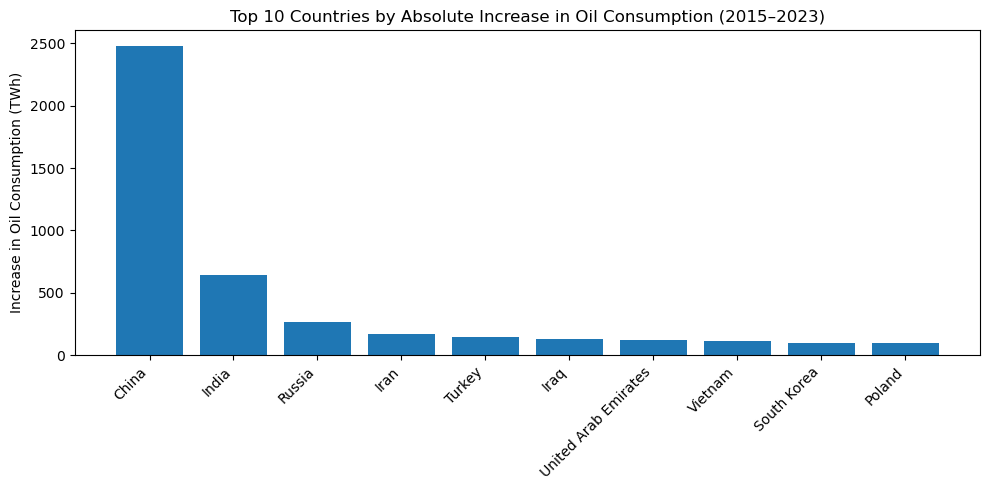

In [44]:
top10_abs = rank.sort_values("abs_change_twh", ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top10_abs["country"], top10_abs["abs_change_twh"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Increase in Oil Consumption (TWh)")
plt.title("Top 10 Countries by Absolute Increase in Oil Consumption (2015–2023)")
plt.tight_layout()
plt.show()


**Key insights:**

- China and India account for the largest absolute increases, making them the primary drivers of global oil demand growth over this period.

- Even though some countries grow fast in percentage terms, this chart shows that large economies dominate total demand growth due to their scale.

- Russia and Iran also show notable increases, reflecting continued dependence on oil for transport and industry.

- Countries like Vietnam and Poland appear here despite smaller economies, indicating structural growth in energy demand in emerging and transitioning markets.

**This chart is most relevant for:**

“Which countries matter most for oil demand in volume terms?”

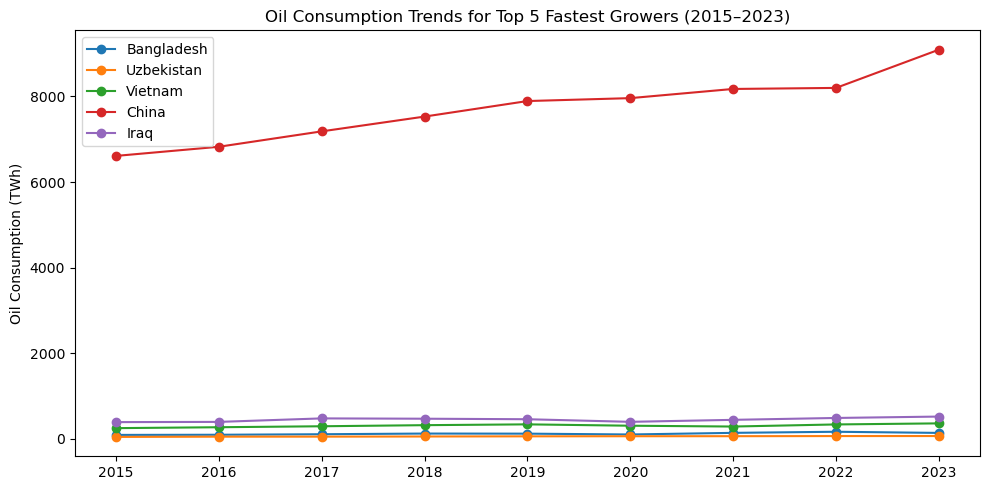

In [46]:
top5 = top10_cagr["country"].head(5).tolist()
df_top5 = df[df["country"].isin(top5)].copy()

plt.figure(figsize=(10,5))
for c in top5:
    tmp = df_top5[df_top5["country"] == c].sort_values("year")
    plt.plot(tmp["year"], tmp["oil_consumption_twh"], marker="o", label=c)

plt.ylabel("Oil Consumption (TWh)")
plt.title("Oil Consumption Trends for Top 5 Fastest Growers (2015–2023)")
plt.legend()
plt.tight_layout()
plt.show()


**Key insights:**

- All five countries show a clear upward trend in oil consumption over time, confirming that their high CAGR is driven by sustained growth rather than one-off spikes.

- Most countries display a dip or slowdown around 2020, reflecting the impact of COVID-19 on transport and industrial activity, followed by recovery afterward.

- China dominates in absolute scale, but Bangladesh, Uzbekistan, and Vietnam show strong relative growth, indicating rapid industrialization and transport demand.

- Iraq’s growth appears more volatile, suggesting that oil consumption may be influenced by economic instability or energy policy changes.

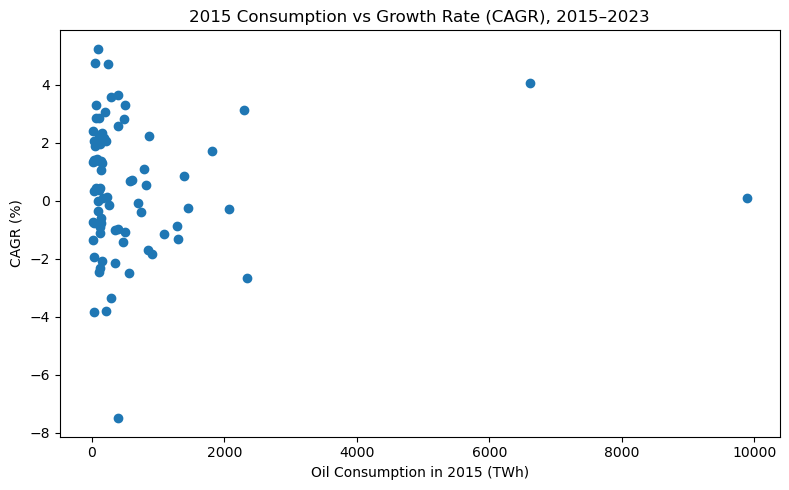

In [48]:
plt.figure(figsize=(8,5))
plt.scatter(rank["oil_2015"], rank["cagr_%"])
plt.xlabel("Oil Consumption in 2015 (TWh)")
plt.ylabel("CAGR (%)")
plt.title("2015 Consumption vs Growth Rate (CAGR), 2015–2023")
plt.tight_layout()
plt.show()


**Key insights:**

- Countries with low oil consumption in 2015 tend to show higher growth rates, indicating a small base effect. Emerging economies can grow fast even with modest absolute demand.

- Large consumers (far right of the chart) generally show moderate growth, meaning global demand growth is driven by both: scale (large countries like China, India), and speed (smaller fast-growing countries like Bangladesh or Uzbekistan).

- A few countries show negative CAGR, meaning their oil consumption declined between 2015 and 2023, likely due to efficiency gains, fuel switching, or economic slowdown.

This chart highlights that fast growth does not always mean large volume impact - some fast growers still contribute relatively small absolute demand.

### Overall business takeaway

Global oil demand growth between 2015 and 2023 is driven by:

- Large economies (China, India) in absolute terms, and

- Rapidly developing economies (Bangladesh, Vietnam, Uzbekistan) in growth rate terms.

- Policymakers and energy planners should expect future demand pressure from emerging markets, even as some mature economies stabilize or decline.

In [57]:
# 1) Ranking / summary table (main dashboard table)
rank.to_csv("oil_consumption_growth_rankings_2015_2023.csv", index=False)

# 2) Clean country-year time series (trend table)
df.to_csv("oil_consumption_country_year_2015_2023.csv", index=False)

print("Saved:",
      "oil_consumption_growth_rankings_2015_2023.csv",
      "oil_consumption_country_year_2015_2023.csv")


Saved: oil_consumption_growth_rankings_2015_2023.csv oil_consumption_country_year_2015_2023.csv
